# Testing Merging of all datasets

In [1]:
from src.common_imports import *

Loading Libraries
Done loading


In [2]:
df_clinical = pd.read_parquet('../mid_processing_datasets/clinical_merged.parquet')
df_protogen = pd.read_parquet('../mid_processing_datasets/protogen_merged_bl.parquet')
df_exp_bl = pd.read_parquet('../mid_processing_datasets/expression_matrix_baseline.parquet')
df_exp_m6 = pd.read_parquet('../mid_processing_datasets/expression_matrix_6month.parquet')

In [3]:
# Nur TAC-Patienten in Proteomics
df_exp_tac_bl = df_exp_bl[df_exp_bl['Patient_ID'].str.startswith('TAC')]
df_exp_tac_m6 = df_exp_m6[df_exp_m6['Patient_ID'].str.startswith('TAC')]
# IDs als Sets
exp_bl_ids = set(df_exp_tac_bl['Patient_ID'])
exp_m6_ids = set(df_exp_tac_m6['Patient_ID'])
protogen_ids = set(df_protogen['Patient_ID'])
clinical_ids = set(df_clinical['Patient_ID'])

# Einzelmengen
print(f"Proteomics Baseline TAC patients: {len(exp_bl_ids)}")
print(f"Proteomics 6 month TAC patients: {len(exp_m6_ids)}")
print(f"Protogen patients: {len(protogen_ids)}")
print(f"Clinical patients: {len(clinical_ids)}")

# Schnittmengen (paarweise)
print(f"\nPaarweise Überschneidung:")
print(f"  Proteomics bl ∩ Protogen: {len(exp_bl_ids & protogen_ids)}")
print(f"  Proteomics bl ∩ Clinical: {len(exp_bl_ids & clinical_ids)}")
print(f"  Proteomics m6 and Protgen: {len(exp_m6_ids & protogen_ids)}")
print(f"  Proteomics m6 and Clinical {len(exp_m6_ids & clinical_ids)}")
print(f"  Protogen ∩ Clinical:   {len(protogen_ids & clinical_ids)}")

# Schnittmenge ALLER drei
in_all = exp_bl_ids & exp_m6_ids & protogen_ids & clinical_ids
print(f"\nIn allen drei Datasets: {len(in_all)}")

# Nur in einem (nicht in den anderen zwei)
only_exp_bl = exp_bl_ids - exp_m6_ids - protogen_ids - clinical_ids
only_exp_m6 = exp_m6_ids - exp_bl_ids - protogen_ids - clinical_ids
only_protogen = protogen_ids - exp_bl_ids - exp_m6_ids - clinical_ids
only_clinical = clinical_ids - exp_bl_ids - exp_m6_ids - protogen_ids

print(f"\nExklusiv pro Dataset:")
print(f"  Nur Proteomics baseline: {len(only_exp_bl)}")
print(f"  Only Proteomics m6: {len(only_exp_m6)}")
print(f"  Nur Protogen:   {len(only_protogen)}")
print(f"  Nur Clinical:   {len(only_clinical)}")

# Beispiel-IDs aus der Schnittmenge
if in_all:
    print(f"\nExmaple Id in all four: {list(in_all)[:5]}")

Proteomics Baseline TAC patients: 100
Proteomics 6 month TAC patients: 97
Protogen patients: 265
Clinical patients: 275

Paarweise Überschneidung:
  Proteomics bl ∩ Protogen: 100
  Proteomics bl ∩ Clinical: 100
  Proteomics m6 and Protgen: 97
  Proteomics m6 and Clinical 97
  Protogen ∩ Clinical:   265

In allen drei Datasets: 97

Exklusiv pro Dataset:
  Nur Proteomics baseline: 0
  Only Proteomics m6: 0
  Nur Protogen:   0
  Nur Clinical:   10

Exmaple Id in all four: ['TAC1004', 'TAC1038', 'TAC1089', 'TAC1202', 'TAC1122']


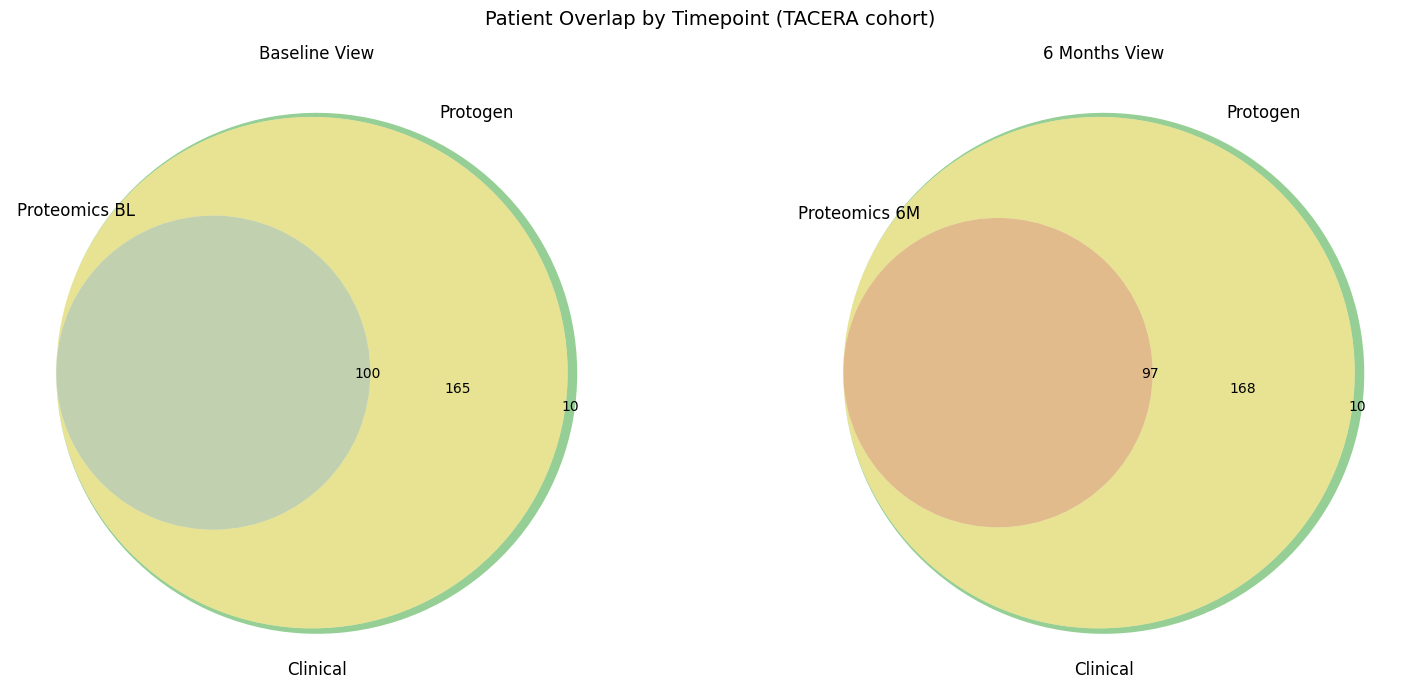

In [4]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Links: Baseline-Sicht
venn3(
    [exp_bl_ids, protogen_ids, clinical_ids],
    set_labels=('Proteomics BL', 'Protogen', 'Clinical'),
    ax=axes[0],
    set_colors=('#1f77b4', '#ff7f0e', '#2ca02c'),
    alpha=0.5,
)
axes[0].set_title('Baseline View')

# Rechts: 6M-Sicht
venn3(
    [exp_m6_ids, protogen_ids, clinical_ids],
    set_labels=('Proteomics 6M', 'Protogen', 'Clinical'),
    ax=axes[1],
    set_colors=('#c40d0d', '#ff7f0e', '#2ca02c'),
    alpha=0.5,
)
axes[1].set_title('6 Months View')

plt.suptitle('Patient Overlap by Timepoint (TACERA cohort)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/dataset_overlap_2venns.png', dpi=100, bbox_inches='tight')
plt.show()

In [5]:
# Die 100 Patienten die in allen drei Datasets sind
common_ids = exp_bl_ids & exp_m6_ids & protogen_ids & clinical_ids
print(f"Patienten mit allen drei Modalitäten: {len(common_ids)}")
print(f"Beispiele: {sorted(common_ids)[:5]}")

Patienten mit allen drei Modalitäten: 97
Beispiele: ['TAC1000', 'TAC1001', 'TAC1002', 'TAC1003', 'TAC1004']


In [6]:
# Jeder Datensatz auf gemeinsame Patienten reduzieren
df_exp_common = df_exp_tac_bl[df_exp_tac_bl['Patient_ID'].isin(common_ids)].copy()
df_exp_m6_common = df_exp_tac_m6[df_exp_tac_m6['Patient_ID'].isin(common_ids)].copy()
df_protogen_common = df_protogen[df_protogen['Patient_ID'].isin(common_ids)].copy()
df_clinical_common = df_clinical[df_clinical['Patient_ID'].isin(common_ids)].copy()

print(f"Proteomics: {df_exp_common.shape}")
print(f"Proteomics m6: {df_exp_m6_common}")
print(f"Protogen:   {df_protogen_common.shape}")
print(f"Clinical:   {df_clinical_common.shape}")

Proteomics: (97, 1311)
Proteomics m6: SeqId      Patient_ID  2597-8_3  2654-19_1  2788-55_1  2967-8_1  3046-31_1  \
SampleId                                                                     
TAC1075_M6    TAC1075   11993.7     1358.4      585.6   14119.3      997.0   
TAC1148_M6    TAC1148   11000.8     1087.1      602.3   13485.6     1186.2   
TAC1179_M6    TAC1179   15116.4     1205.6      382.9   13505.8     1155.5   
TAC1225_M6    TAC1225   12873.1     2062.8     1243.5   20003.1     1864.4   
TAC1209_M6    TAC1209   10796.4     1178.1     1136.9   15152.3     1364.6   
...               ...       ...        ...        ...       ...        ...   
TAC1037_M6    TAC1037    8826.8     1352.9      640.3    9035.7     1231.1   
TAC1064_M6    TAC1064   11922.5     1328.1      717.5   12123.8      914.2   
TAC1250_M6    TAC1250   12660.8     1468.4      684.1   20276.7     1377.5   
TAC1146_M6    TAC1146    7601.4     1045.7      589.0   12570.1     1817.9   
TAC1095_M6    TAC1095    9

In [7]:
exp_cols = set(df_exp_common.columns)
exp_m6_cols = set(df_exp_m6_common.columns)
protogen_cols = set(df_protogen_common.columns)
clinical_cols = set(df_clinical_common.columns)

print("Überlappende Spalten:")
print(f"  Proteomics bl ∩ Protogen: {len(exp_bl_ids & protogen_ids)}")
print(f"  Proteomics bl ∩ Clinical: {len(exp_bl_ids & clinical_ids)}")
print(f"  Proteomics m6 and Protogen: {len(exp_m6_ids & protogen_ids)}")
print(f"  Proteomics m6 and Clinical {len(exp_m6_ids & clinical_ids)}")
print(f"  Protogen ∩ Clinical:   {len(protogen_ids & clinical_ids)}")


Überlappende Spalten:
  Proteomics bl ∩ Protogen: 100
  Proteomics bl ∩ Clinical: 100
  Proteomics m6 and Protogen: 97
  Proteomics m6 and Clinical 97
  Protogen ∩ Clinical:   265


In [11]:
# Metadata-Spalten die wir nicht doppelt wollen
metadata_to_drop = ['SampleId', 'Timepoint', 'Digest', 'Study']

# Proteomics: nur SampleId entfernen (Patient_ID behalten als Key)
df_exp_clean = df_exp_common.reset_index(drop=False)  # SampleId aus Index zur Spalte
df_exp_clean = df_exp_clean.drop(columns=[c for c in metadata_to_drop if c in df_exp_clean.columns])

df_exp_m6_clean = df_exp_m6_common.reset_index(drop=False)
df_exp_m6_clean = df_exp_m6_clean.drop(columns=[c for c in metadata_to_drop if c in df_exp_m6_clean.columns])

# Protogen: dasselbe
df_protogen_clean = df_protogen_common.drop(
    columns=[c for c in metadata_to_drop if c in df_protogen_common.columns], 
    errors='ignore'
)

# Clinical: dasselbe
df_clinical_clean = df_clinical_common.drop(
    columns=[c for c in metadata_to_drop if c in df_clinical_common.columns], 
    errors='ignore'
)

print(f"Nach Cleanup:")
print(f"  Proteomics: {df_exp_clean.shape}")
print(f"  Proteomics m6: {df_exp_m6_clean.shape}")
print(f"  Protogen:   {df_protogen_clean.shape}")
print(f"  Clinical:   {df_clinical_clean.shape}")

# Join: Clinical → Protogen → Proteomics
df_multi_omics = (
    df_clinical_clean
    .merge(df_protogen_clean, on='Patient_ID', how='inner')
    .merge(df_exp_clean, on='Patient_ID', how='inner')
    .merge(df_exp_m6_clean, on='Patient_ID', how='inner')
)

print(f"\nMulti-omics: {df_multi_omics.shape}")
print(f"Unique Patient_IDs: {df_multi_omics['Patient_ID'].nunique()}")

Nach Cleanup:
  Proteomics: (97, 1311)
  Proteomics m6: (97, 1311)
  Protogen:   (97, 164)
  Clinical:   (97, 67)

Multi-omics: (97, 2850)
Unique Patient_IDs: 97


In [12]:
# Sollte 100 Patienten haben
assert df_multi_omics['Patient_ID'].nunique() == 97, "Patient-Anzahl stimmt nicht!"

# Schauen welche Spalten-Typen
print("\nDatentypen-Übersicht:")
print(df_multi_omics.dtypes.value_counts())

# Erste paar Spalten anschauen
print(f"\nErste 10 Spalten: {df_multi_omics.columns[:10].tolist()}")
print(f"Letzte 5 Spalten: {df_multi_omics.columns[-5:].tolist()}")


Datentypen-Übersicht:
float64           2843
str                  3
datetime64[ns]       2
datetime64[us]       2
Name: count, dtype: int64

Erste 10 Spalten: ['Patient_ID', 'Region', 'Hub', 'REGION_HUB', 'ACPA.POSITIVE', 'RHUEMATOID.FACTOR', 'DAS28.0M', 'DAS28.3M', 'DAS28.6M', 'DAS28.12M']
Letzte 5 Spalten: ['9211-19_3_y', '9212-22_3_y', '9213-24_3_y', '9215-117_3_y', '9216-100_3_y']


In [13]:
datetime_cols = df_multi_omics.select_dtypes(include=['datetime64']).columns.tolist()
print(datetime_cols)

['first_injection', 'last_injection', 'first_med_date', 'last_med_date']


In [14]:
# Testen ob alles speicherbar ist
import os
os.makedirs('../mid_processing_datasets', exist_ok=True)

try:
    df_multi_omics.to_parquet(
        '../mid_processing_datasets/multi_omics_bl.parquet',
        engine='pyarrow'
    )
    print(f"✓ Saved: ../mid_processing_datasets/multi_omics_bl.parquet")
    print(f"✓ Shape: {df_multi_omics.shape}")
except Exception as e:
    print(f"✗ Fehler: {e}")

✓ Saved: ../mid_processing_datasets/multi_omics_bl.parquet
✓ Shape: (97, 2850)


Features: (97, 2843)
Total PCs: 97


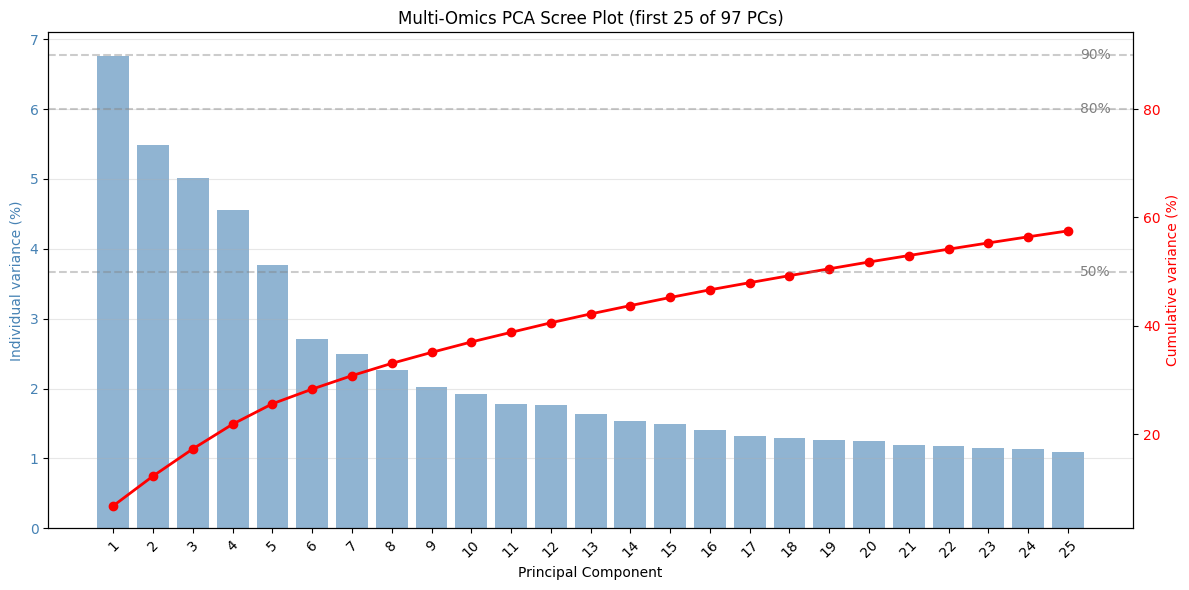


PCs needed for 50% variance: 19
PCs needed for 80% variance: 53
PCs needed for 90% variance: 71


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# 1. Multi-Omics laden
df_multi_omics = pd.read_parquet('../mid_processing_datasets/multi_omics_bl.parquet')

# 2. Nur numerische Features
feature_cols = df_multi_omics.select_dtypes(include='number').columns.tolist()
X = df_multi_omics[feature_cols].copy()

# 3. Missings imputieren
X_imputed = X.fillna(X.median())

# 4. Standardisieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 5. PCA mit allen möglichen Komponenten
pca = PCA()
pcs = pca.fit_transform(X_scaled)

print(f"Features: {X.shape}")
print(f"Total PCs: {len(pca.explained_variance_ratio_)}")

# 6. Scree Plot
n_show = 25   # erste 30 PCs anzeigen
explained = pca.explained_variance_ratio_[:n_show]
cumulative = np.cumsum(pca.explained_variance_ratio_)[:n_show]

fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(1, n_show + 1)

# Balken: individuelle Varianz
ax1.bar(x, explained * 100, alpha=0.6, color='steelblue', label='Individual')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Individual variance (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Linie: kumulative Varianz
ax2 = ax1.twinx()
ax2.plot(x, cumulative * 100, 'ro-', linewidth=2, markersize=6, label='Cumulative')
ax2.set_ylabel('Cumulative variance (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Referenzlinien bei 50%, 80%, 90%
for threshold in [50, 80, 90]:
    ax2.axhline(y=threshold, color='gray', linestyle='--', alpha=0.4)
    ax2.text(n_show + 0.3, threshold, f'{threshold}%', color='gray', va='center')

ax1.set_title(f'Multi-Omics PCA Scree Plot (first {n_show} of {len(pca.explained_variance_ratio_)} PCs)')
ax1.set_xticks(x)
ax1.set_xticklabels(x, rotation=45)
ax1.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/multi_omics_pca_scree.png', dpi=100, bbox_inches='tight')
plt.show()

# 7. Ausgabe wie viele PCs für die Schwellen
cum_all = np.cumsum(pca.explained_variance_ratio_)
n_50 = np.argmax(cum_all >= 0.50) + 1
n_80 = np.argmax(cum_all >= 0.80) + 1
n_90 = np.argmax(cum_all >= 0.90) + 1
print(f"\nPCs needed for 50% variance: {n_50}")
print(f"PCs needed for 80% variance: {n_80}")
print(f"PCs needed for 90% variance: {n_90}")